Сравним наилучший baseline из предыдущего шага с нейросетевыми решениями

In [1]:
%load_ext autoreload 
%autoreload 2

## Импорт необходимых библиотек и модулей

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

In [5]:
import torch.nn as nn
import torch.optim as optim

In [6]:
from core.utils import *
from core.nlp import *
from core.visualization import *
from core.baseline_training import *
from core.vectorization import *
from core.nn_models import *
from core.nn_training import *

Для воспроизводимости экспериментов

In [7]:
SEED = 316

init_random_seed(SEED)

## Препроцессинг и лучший baseline

In [8]:
data_path = 'data'

In [9]:
data = pd.read_csv(f"{data_path}/ecommerceDataset.csv", header=None, names=["category", "description"])
data.sample(5)

,category,description
6692,Household,Handmade Butterfly Beaded Napkin Rings Set Of ...
37043,Clothing & Accessories,Urbaano G-Strings Eco Pack of Three A very hot...
48509,Electronics,By Pioneer BDP-180 Network 3D Blu-Ray Player w...
16111,Household,Mitashi 6.2 kg Fully-Automatic Top Loading Was...
23949,Books,Fear: Trump in the White House Review `As spec...


Повторим последовательность шагов по препроцессингу данных, аналогичную выполненным при построении baseline и воспроизведем наилучшее решение среди рассмотренных ранее базовых алгоритмов

In [10]:
data_preprocessed = data.copy()

data_preprocessed.dropna(inplace=True)
data_preprocessed.drop_duplicates(inplace=True)
data_preprocessed['description'] = data_preprocessed['description'].apply(tokenize_tiktoken)

print(data_preprocessed.shape)
data_preprocessed.sample(5)

(27802, 2)


,category,description
21219,Books,"[the, land, of, stories, :, worlds, coll, ide,..."
769,Household,"[space, wood, ci, ara, dress, er, table, with,..."
36248,Clothing & Accessories,"[v, ., k, ., jew, els, silver, twin, leaf, rh,..."
9399,Household,"[emb, assy, stainless, steel, multip, urpose, ..."
35221,Clothing & Accessories,"[am, erican, cre, w, men, 's, polyester, track..."


In [11]:
X, y = divide_data(data_preprocessed, 'category')

In [12]:
logreg_classifier = LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')
logreg_classifier

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,316
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv

StratifiedKFold(n_splits=5, random_state=316, shuffle=True)

In [14]:
count_vectorizer_processor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            ('prompt_vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'description'),
        ],
        remainder='passthrough',
        verbose_feature_names_out=True
    ))
])

count_vectorizer_processor

,steps,"[('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('prompt_vectorizer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


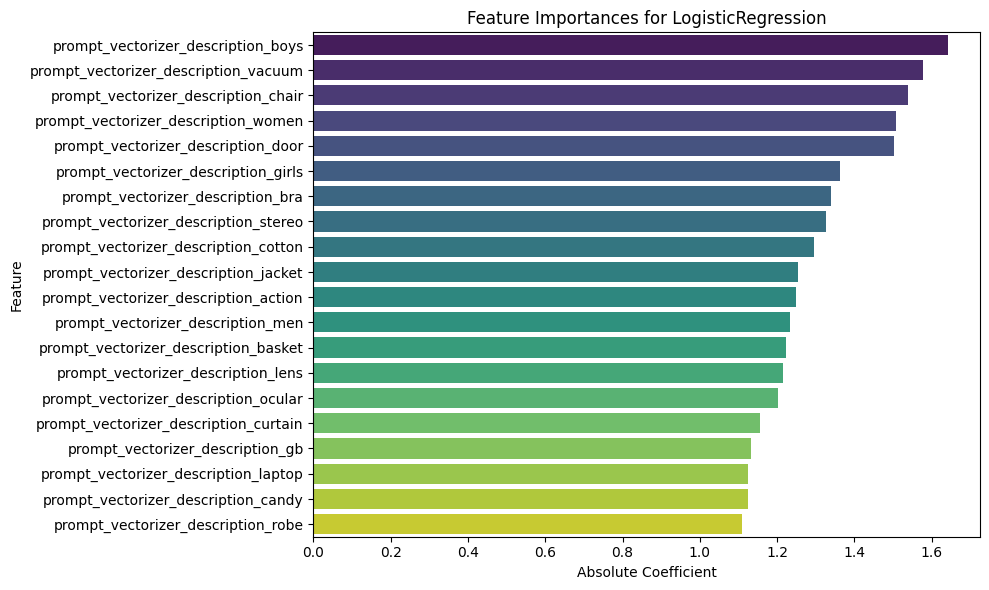

In [40]:
baseline_metrics, baseline_pipeline = train_evaluate_model_cv(model=logreg_classifier, model_name='LogisticRegression', X=X, y=y, 
                                                              preprocessor=count_vectorizer_processor, cv=cv, seed=SEED)

Посмотрим на метрики качества базового решения

In [41]:
baseline_metrics.to_compact_dict()

{'ROC AUC': nan,
 'F1 Score': 0.935450213183778,
 'Precision': 0.9365328795926754,
 'Recall': 0.9345777425840887,
 'Accuracy': 0.9362278794119892,
 'Training Time (s)': 55.21141481399536}

## Препроцессинг перед использованием нейросетей

Так как нейронные сети работают с последовательностями токенов, они не могут напрямую работать с несколькими отдельными текстами. Объединим их

In [17]:
data_nn = data.copy()

data_nn.dropna(inplace=True)
data_nn.drop_duplicates(inplace=True)
data_nn['description'] = data_nn['description'].apply(tokenize_tiktoken)
data_nn['category_id'] = data_nn['category'].map(category_codes)

print(data_nn.shape)
data_nn.sample(5)

(27802, 3)


,category,description,category_id
730,Household,"[n, isha, furniture, she, esh, am, wood, bed, ...",0
10010,Household,"[dark, py, ros, 6, pcs, prim, ium, quality, mu...",0
40663,Electronics,"[ap, c, be, 800, -, ind, 12, ah, b, uiltin, up...",3
6092,Household,"[only, mat, co, ir, door, mats, ,, 30, "", x, 1...",0
10875,Household,"[s, erves, afe, stainless, steel, colour, c, o...",0


In [18]:
input_token_counts = token_counts(
    data_nn,
    'description',
    remove_stopwords=True,
    remove_punctuation=True,
    lowercase_for_counting=True
)

Определим максимальную длину последовательности для использования паддинга/усечения при пакетной обработке данных нейросетями

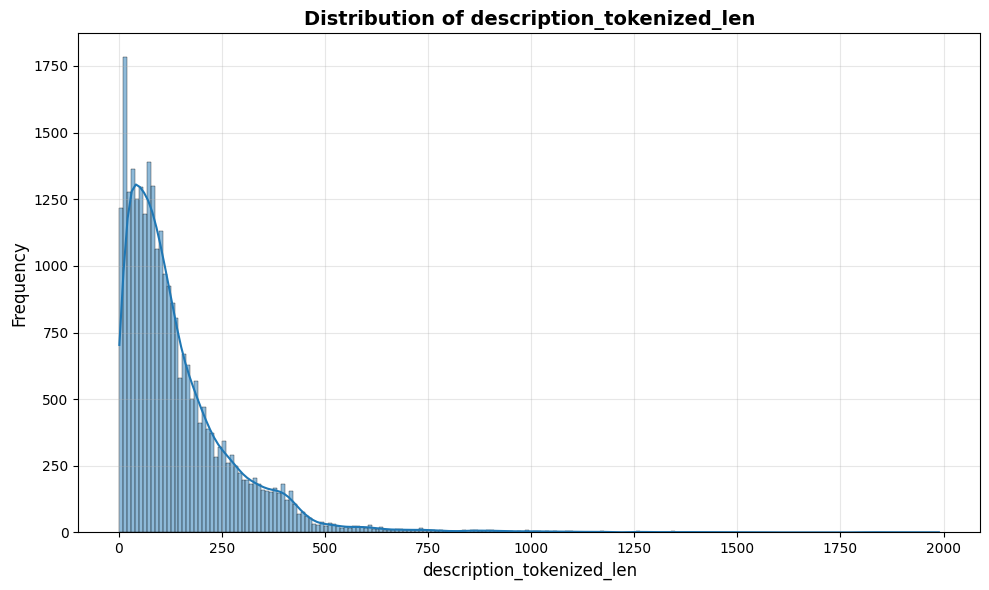

In [19]:
data_nn['description_tokenized_len'] = data_nn['description'].apply(len)
data_nn_filtered = data_nn[data_nn['description_tokenized_len'] < 2000]

plot_histogram_numeric(data_nn_filtered, 'description_tokenized_len', figsize=(10, 6))

data_nn.drop(columns=['description_tokenized_len'], inplace=True)

Для максимально полного анализа текстов откажемся лишь от малозаметного хвоста распределения и будем анализировать только первые 500 токенов последовательностей

In [20]:
MAX_SEQUENCE_LENGTH = 500 

In [21]:
vectorizer = SequenceVectorizer(max_length=MAX_SEQUENCE_LENGTH, pad_left=False)
input_vectorized = vectorizer.fit_transform(data_nn['description'])

input_vectorized.shape

(27802, 500)

Пайплайн предобработки текстов для нейронных сетей

In [22]:
basic_preprocessor = Pipeline([
    ('vectorizer', vectorizer)
])

basic_preprocessor

,steps,"[('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,min_frequency,1
,max_vocab_size,None
,pad_token,'<PAD>'
,oov_token,'<OOV>'
,pad_left,False
,max_length,500
,dtype,'int32'


## RNN (Рекуррентная нейронная сеть)

RNN обрабатывает последовательности токенов слева направо, сохраняя информацию о предыдущих токенах. Используем Bidirectional RNN для анализа контекста в обе стороны

Определим гиперпараметры RNN и процесса обучения

In [44]:
LEARNING_RATE = 1e-3        
BATCH_SIZE = 256           
RNN_UNITS = 64              
EMBEDDING_DIM = 256         

DROPOUT_RATE = 0.2         
RECCURENT_DROPOUT_RATE = 0 

REGULARIZATION_STRENGTH = 1e-4

Выберем наиболее оптимальное устройство для обучения

In [24]:
device = get_device()

device

device(type='cuda')

Построим саму модель

In [45]:
rnn_model = RNNForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    rnn_units=RNN_UNITS,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECCURENT_DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id,
    num_classes=4,
).to(device)

rnn_model

RNNForCategoryClassification(
  (embedding): Embedding(31217, 256, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [46]:
print(f"Рекуррентная модель содержит число параметров: {count_parameters(rnn_model)}")

Рекуррентная модель содержит число параметров: 8033284


Поскольку наши данные содержат дисбаланс, мы внесем эту информацию в функцию потерь с помощью настраиваемого веса положительного класса. Вычислим его

In [47]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(data_nn["category_id"]),
    y=data_nn["category_id"],
)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
class_weights

tensor([0.6579, 1.1110, 1.2250, 1.3094], device='cuda:0')

Определим функцию потерь и оптимизатор

In [48]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}

Запустим обучение RNN


🌀 Fold 1/5


Training fold 1: 100%|██████████| 50/50 [01:12<00:00,  1.45s/it, loss=0.0367]


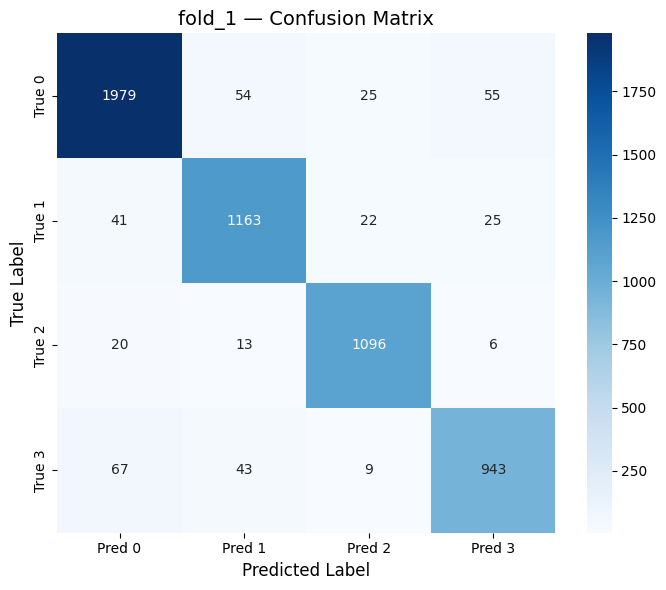


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9859
 F1 Score 0.9300
Precision 0.9302
   Recall 0.9300
 Accuracy 0.9317


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.939250 0.936583
    1   0.913590 0.929656
    2   0.951389 0.965639
    3   0.916424 0.887947


🌀 Fold 2/5


Training fold 2: 100%|██████████| 50/50 [01:12<00:00,  1.44s/it, loss=0.0318]


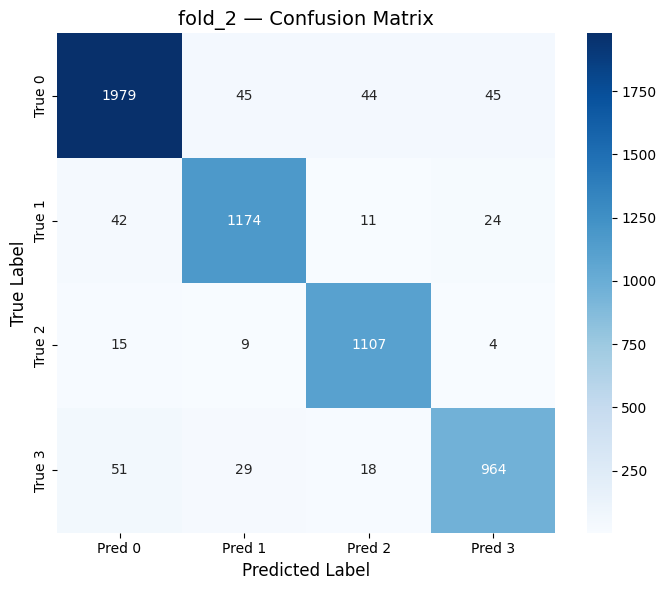


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9846
 F1 Score 0.9384
Precision 0.9375
   Recall 0.9395
 Accuracy 0.9394


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.948251 0.936583
    1   0.933970 0.938449
    2   0.938136 0.975330
    3   0.929605 0.907721


🌀 Fold 3/5


Training fold 3: 100%|██████████| 50/50 [01:11<00:00,  1.42s/it, loss=0.0405]


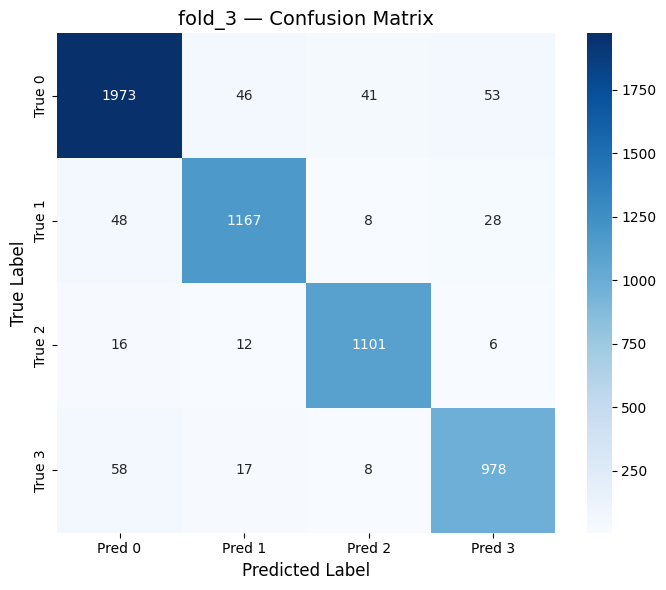


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9862
 F1 Score 0.9386
Precision 0.9376
   Recall 0.9396
 Accuracy 0.9387


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.941766 0.933743
    1   0.939614 0.932854
    2   0.950777 0.970044
    3   0.918310 0.921772


🌀 Fold 4/5


Training fold 4: 100%|██████████| 50/50 [01:11<00:00,  1.43s/it, loss=0.0400]


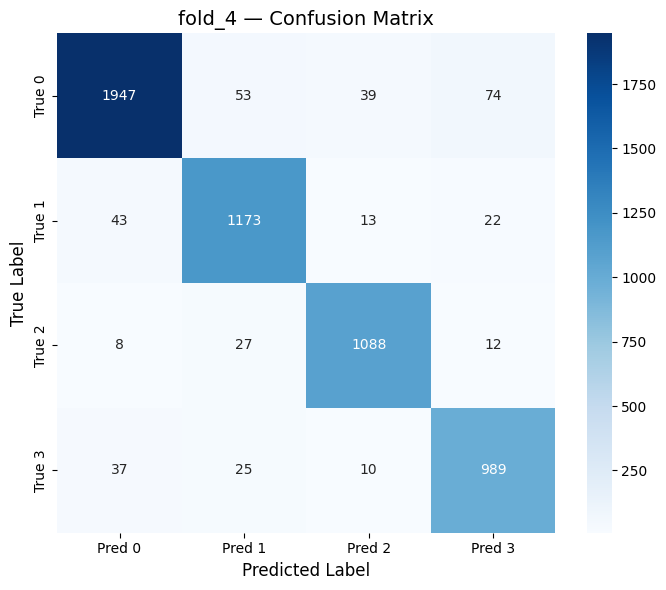


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9871
 F1 Score 0.9338
Precision 0.9306
   Recall 0.9375
 Accuracy 0.9347


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.956757 0.921439
    1   0.917840 0.937650
    2   0.946087 0.958590
    3   0.901550 0.932139


🌀 Fold 5/5


Training fold 5: 100%|██████████| 50/50 [01:11<00:00,  1.43s/it, loss=0.0355]


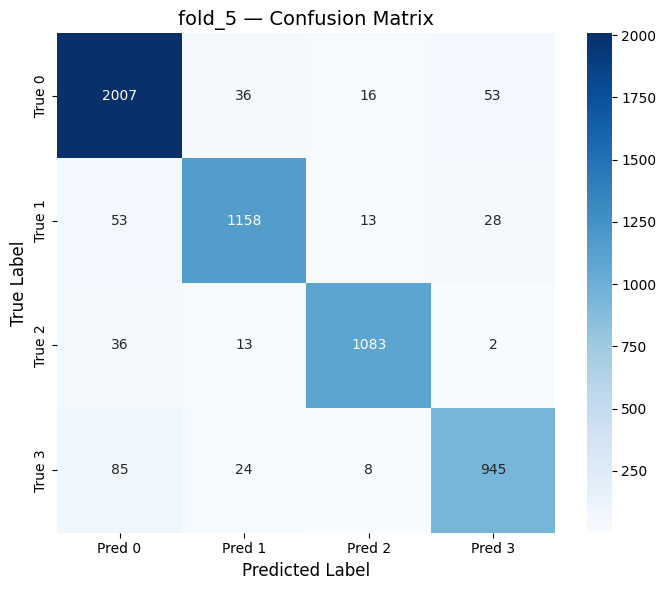


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9856
 F1 Score 0.9333
Precision 0.9368
   Recall 0.9300
 Accuracy 0.9340


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.920220 0.950284
    1   0.940699 0.924920
    2   0.966964 0.955026
    3   0.919261 0.889831



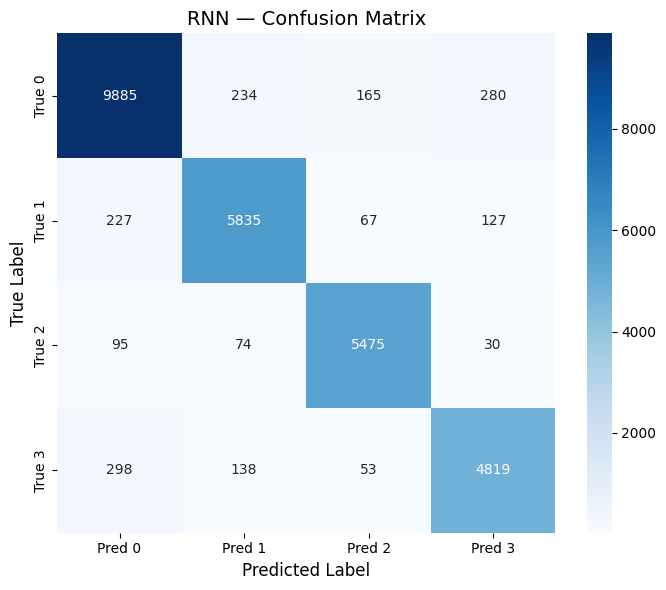

CPU times: total: 6min 9s
Wall time: 6min 9s


ClassificationMetrics(name='RNN', training_time=358.996601400082, estimators=[{'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': RNNForCategoryClassification(
  (embedding): Embedding(31217, 256, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': RNNForCategoryClassification(
  (embedding): Embedding(31217, 256, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': RNNForCategoryClassification(
  (embedd

In [49]:
%%time

rnn_metrics = cross_validate_model(
    model=rnn_model,
    X=data_nn['description'],
    y=data_nn['category_id'],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='RNN'
)

rnn_metrics

Видим что RNN справилась примерно также, как базовая модель. Проверим другие архитектуры

In [50]:
free_memory()

## CNN (Сверточная нейронная сеть)

CNN применяет сверточные фильтры к последовательности токенов, выявляя локальные паттерны. GlobalMaxPooling1D выбирает наиболее важные признаки из всей последовательности. CNN часто работают быстрее RNN и могут выявлять n-граммы эффективнее.

Определим гиперпараметры CNN

In [51]:
BATCH_SIZE = 128
EMBEDDING_DIM = 512
FILTERS = 10
KERNEL_SIZE = 3

Построим модель

In [52]:
cnn_model = CNNForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    num_filters=FILTERS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id
).to(device)

cnn_model

CNNForCategoryClassification(
  (embedding): Embedding(31217, 512, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(512, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=4, bias=True)
)

In [53]:
print(f"Сверточная модель содержит число параметров: {count_parameters(cnn_model)}")

Сверточная модель содержит число параметров: 15998518


Запустим процесс обучения


🌀 Fold 1/5


Training fold 1: 100%|██████████| 50/50 [01:52<00:00,  2.25s/it, loss=0.0214]


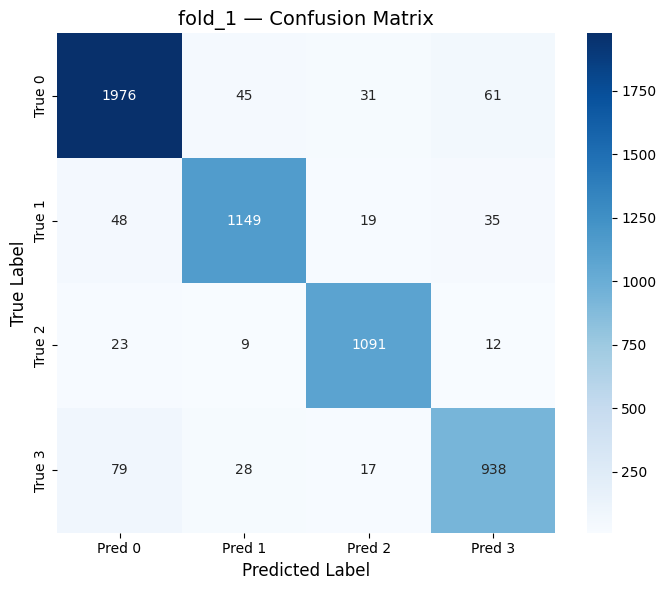


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9860
 F1 Score 0.9249
Precision 0.9254
   Recall 0.9245
 Accuracy 0.9268


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.929445 0.935163
    1   0.933387 0.918465
    2   0.942142 0.961233
    3   0.896750 0.883239


🌀 Fold 2/5


Training fold 2: 100%|██████████| 50/50 [01:53<00:00,  2.27s/it, loss=0.0201]


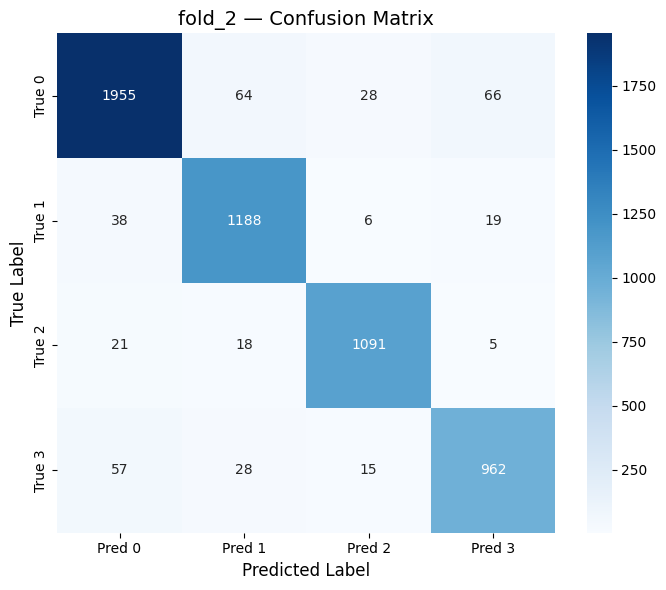


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9866
 F1 Score 0.9340
Precision 0.9327
   Recall 0.9355
 Accuracy 0.9344


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.943988 0.925225
    1   0.915254 0.949640
    2   0.957018 0.961233
    3   0.914449 0.905838


🌀 Fold 3/5


Training fold 3: 100%|██████████| 50/50 [01:52<00:00,  2.26s/it, loss=0.0178]


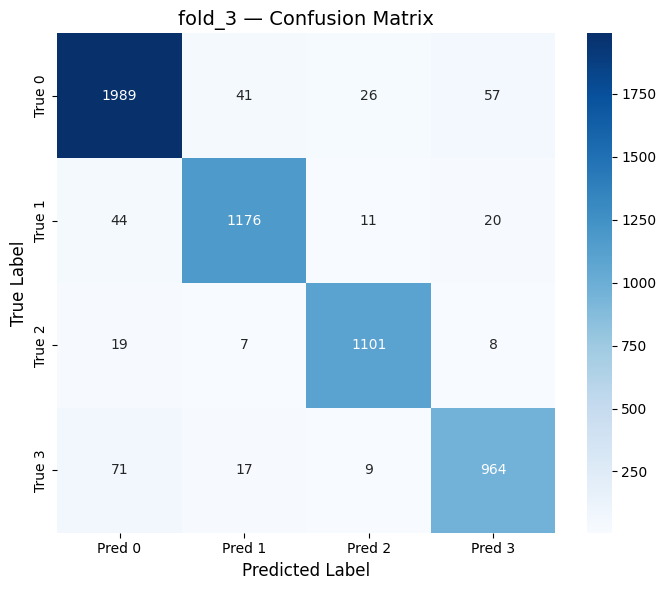


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9889
 F1 Score 0.9404
Precision 0.9408
   Recall 0.9400
 Accuracy 0.9406


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.936882 0.941316
    1   0.947623 0.940048
    2   0.959895 0.970044
    3   0.918970 0.908577


🌀 Fold 4/5


Training fold 4: 100%|██████████| 50/50 [01:52<00:00,  2.26s/it, loss=0.0183]


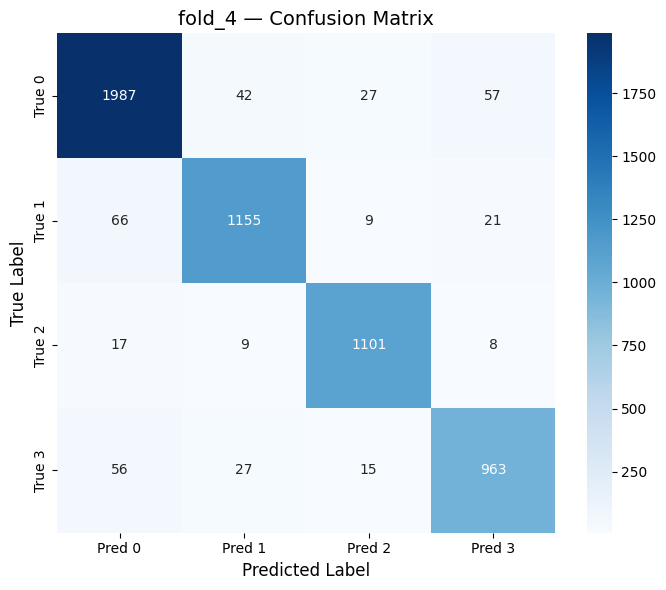


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9887
 F1 Score 0.9358
Precision 0.9363
   Recall 0.9353
 Accuracy 0.9363


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.934619 0.940369
    1   0.936740 0.923261
    2   0.955729 0.970044
    3   0.918017 0.907634


🌀 Fold 5/5


Training fold 5: 100%|██████████| 50/50 [01:52<00:00,  2.24s/it, loss=0.0163]


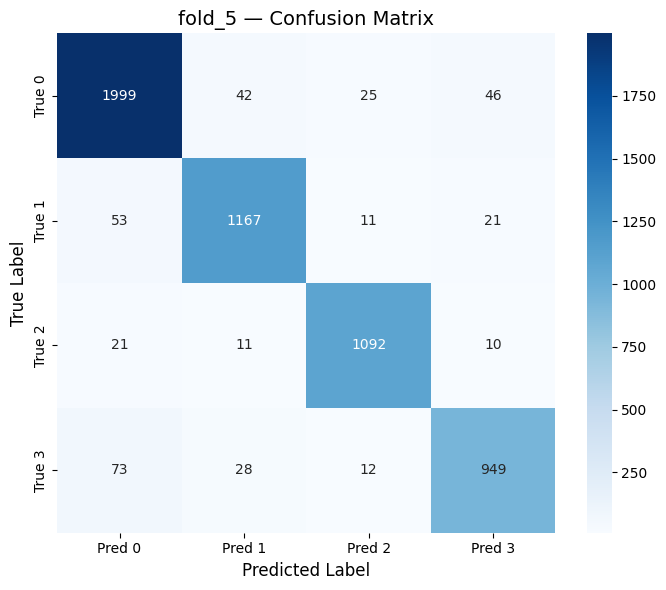


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9875
 F1 Score 0.9355
Precision 0.9374
   Recall 0.9338
 Accuracy 0.9365


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.931500 0.946496
    1   0.935096 0.932109
    2   0.957895 0.962963
    3   0.924951 0.893597



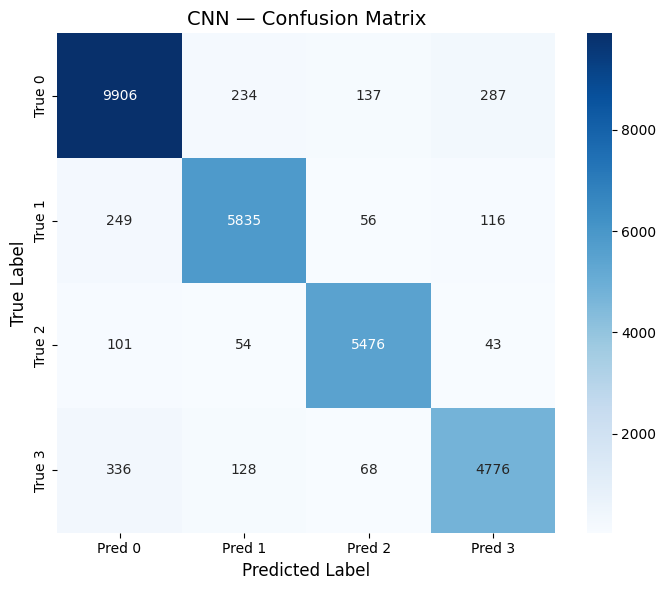

CPU times: total: 9min 28s
Wall time: 9min 35s


ClassificationMetrics(name='CNN', training_time=563.9100227999734, estimators=[{'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': CNNForCategoryClassification(
  (embedding): Embedding(31217, 512, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(512, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=4, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': CNNForCategoryClassification(
  (embedding): Embedding(31217, 512, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(512, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=4, bias=True)
)}, {'preprocessor': Pipeline(steps=[

In [54]:
%%time

cnn_metrics = cross_validate_model(
    model=cnn_model,
    X=data_nn['description'],
    y=data_nn['category_id'],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='CNN'
)

cnn_metrics

Видно, что CNN также несильно отличается от предыдущих моделей, но скорость обучения снизилась

In [55]:
free_memory()

## LSTM (Сеть долгой краткосрочной памяти)

LSTM является улучшенной версией RNN с оптимизациями направленными на решение проблем длинных зависимостей и на лучший учет контекста

Определим параметры LSTM

In [29]:
LSTM_UNITS = 64
EMBEDDING_DIM = 256

Построим модель

In [30]:
lstm_model = LSTMForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECCURENT_DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id
).to(device)

lstm_model

LSTMForCategoryClassification(
  (embedding): Embedding(31217, 256, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [31]:
print(f"LSTM содержит число параметров: {count_parameters(lstm_model)}")

LSTM содержит число параметров: 8156932


Запустим процесс обучения


🌀 Fold 1/5


Training fold 1: 100%|██████████| 50/50 [01:54<00:00,  2.29s/it, loss=0.0325]


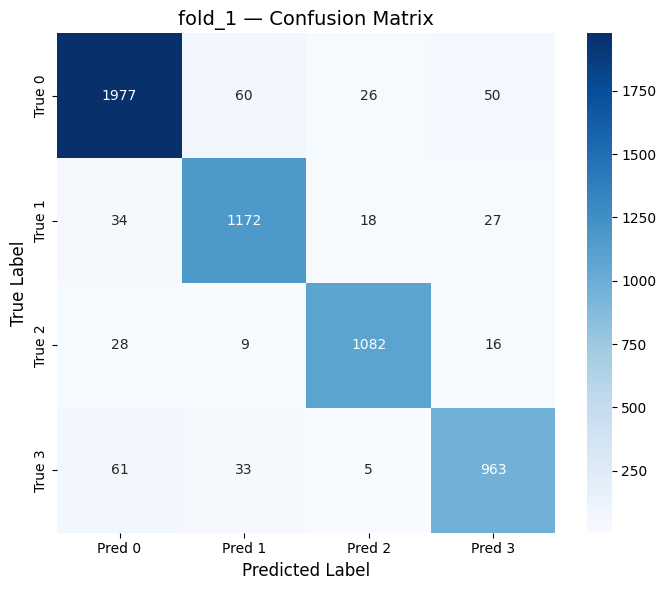


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9879
 F1 Score 0.9328
Precision 0.9325
   Recall 0.9331
 Accuracy 0.9340


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.941429 0.935637
    1   0.919937 0.936851
    2   0.956676 0.953304
    3   0.911932 0.906780


🌀 Fold 2/5


Training fold 2: 100%|██████████| 50/50 [01:54<00:00,  2.28s/it, loss=0.0264]


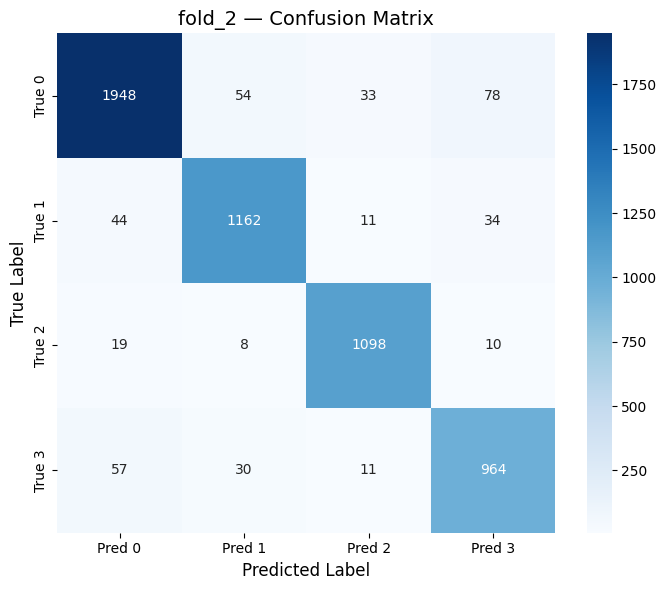


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9839
 F1 Score 0.9292
Precision 0.9271
   Recall 0.9315
 Accuracy 0.9300


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.941973 0.921912
    1   0.926635 0.928857
    2   0.952298 0.967401
    3   0.887661 0.907721


🌀 Fold 3/5


Training fold 3: 100%|██████████| 50/50 [01:54<00:00,  2.28s/it, loss=0.0291]


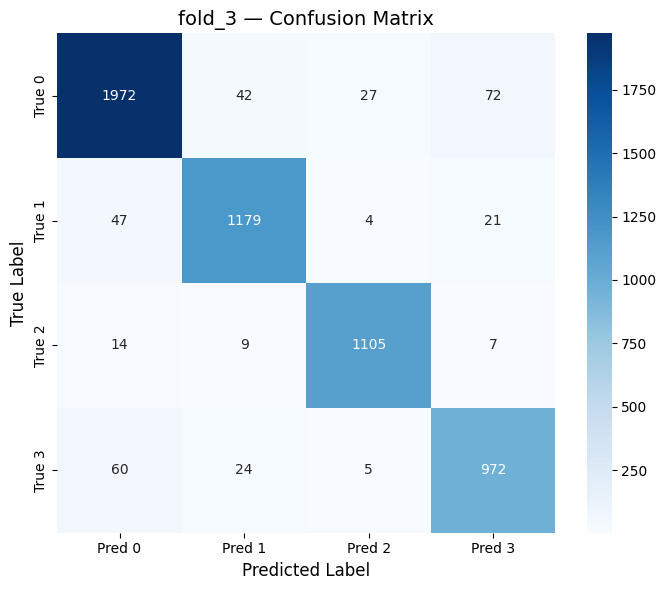


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9868
 F1 Score 0.9404
Precision 0.9394
   Recall 0.9414
 Accuracy 0.9403


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.942188 0.933270
    1   0.940191 0.942446
    2   0.968449 0.973568
    3   0.906716 0.916117


🌀 Fold 4/5


Training fold 4: 100%|██████████| 50/50 [01:55<00:00,  2.30s/it, loss=0.0249]


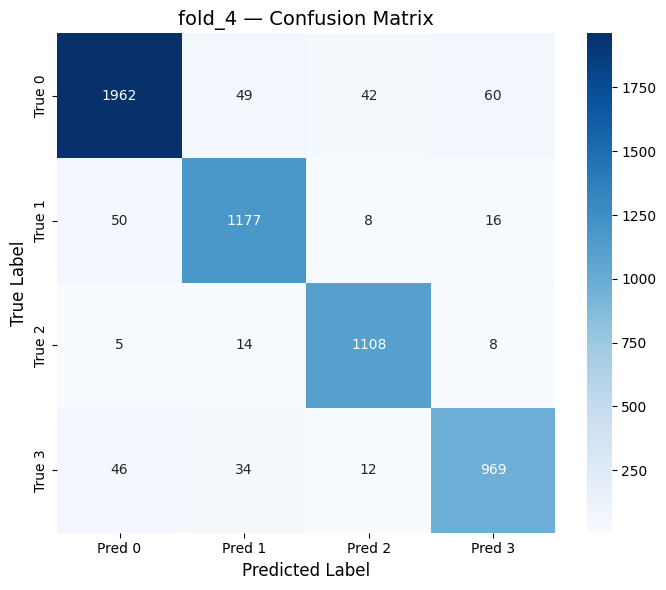


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9878
 F1 Score 0.9375
Precision 0.9355
   Recall 0.9397
 Accuracy 0.9381


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.951042 0.928538
    1   0.923862 0.940847
    2   0.947009 0.976211
    3   0.920228 0.913289


🌀 Fold 5/5


Training fold 5: 100%|██████████| 50/50 [01:54<00:00,  2.29s/it, loss=0.0307]


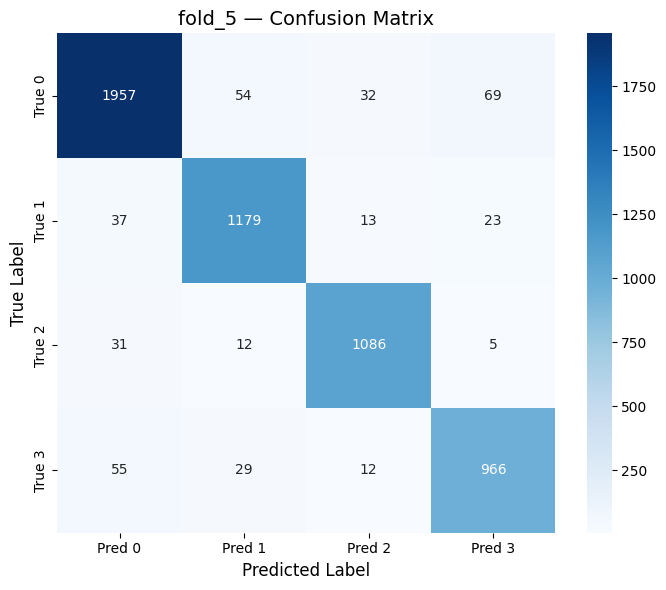


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9862
 F1 Score 0.9326
Precision 0.9313
   Recall 0.9339
 Accuracy 0.9331


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.940865 0.926610
    1   0.925432 0.941693
    2   0.950131 0.957672
    3   0.908749 0.909605



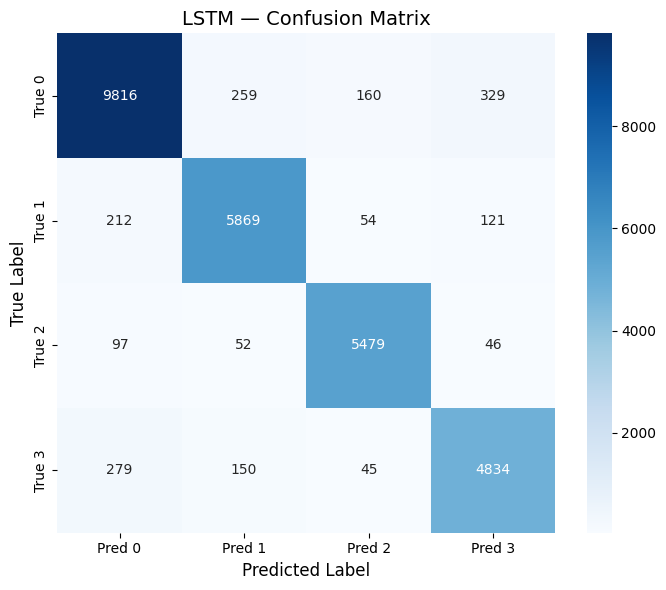

CPU times: total: 9min 41s
Wall time: 9min 44s


ClassificationMetrics(name='LSTM', training_time=572.3727104001446, estimators=[{'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': LSTMForCategoryClassification(
  (embedding): Embedding(31217, 256, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': LSTMForCategoryClassification(
  (embedding): Embedding(31217, 256, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))]), 'model': LSTMForCategoryClassification(


In [32]:
%%time

lstm_metrics = cross_validate_model(
    model=lstm_model,
    X=data_nn['description'],
    y=data_nn['category_id'],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='LSTM'
)

lstm_metrics

Видно что LSTM также несильно отличается от предыдущих моделей

## Предобученные GloVe эмбеддинги + CNN

Суть подхода - не тратить время на обучение собственной матрицы эмбеддингов, а использовать уже предобученные. Выходы эмбеддингов будут подаваться на сверточный слой - показавший себя лучшим среди прочих архитектур, после чего также будет применен линейный слой классификации

Определим параметры GloVe. Файл с эмбеддингами можно найти по [ссылке](https://huggingface.co/spaces/lwdragon/lstm_mindspore/blob/main/glove.6B.100d.txt)

In [33]:
GLOVE_DIM = 100
GLOVE_MAX_VOCAB = 20000
GLOVE_PATH: str = 'glove/glove.6B.100d.txt'

Определим гиперпараметры сети и процесса обучения

In [34]:
LEARNING_RATE = 1e-3        
BATCH_SIZE = 128
FILTERS = 10
KERNEL_SIZE = 3
REGULARIZATION_STRENGTH = 1e-4
MAX_SEQUENCE_LENGTH = 1000

Загрузим GloVe эмбеддинги и построим препроцессор

In [36]:
glove_vocab, glove_matrix = load_glove_fixed_vocab(GLOVE_PATH, GLOVE_DIM, GLOVE_MAX_VOCAB)
glove_preprocessor = SequenceVectorizer(max_length=MAX_SEQUENCE_LENGTH, vocabulary=glove_vocab, pad_left=False)
glove_preprocessor

,min_frequency,1
,max_vocab_size,None
,pad_token,'<PAD>'
,oov_token,'<OOV>'
,pad_left,False
,max_length,1000
,dtype,'int32'
,vocabulary,"{'!': 807, '""': 10, '#': 2751, '$': 82, ...}"


Построим саму модель

In [37]:
glove_cnn_model = GloveCNNForCategoryClassification(
    glove_matrix=glove_matrix,
    num_filters=FILTERS,
    kernel_size=KERNEL_SIZE
).to(device)

glove_cnn_model

GloveCNNForCategoryClassification(
  (embedding): Embedding(20003, 100, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv): Conv1d(100, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=4, bias=True)
)

In [38]:
print(f"Сверточная модель с GloVe эмбеддингами содержит число параметров: {count_parameters(glove_cnn_model)}")
print(f"Сверточная модель с GloVe эмбеддингами содержит число обучаемых параметров: {count_trainable_parameters(glove_cnn_model)}")

Сверточная модель с GloVe эмбеддингами содержит число параметров: 2003354
Сверточная модель с GloVe эмбеддингами содержит число обучаемых параметров: 3054


Можно заметить, что обучаемых параметров практически в 1000 раз меньше чем параметров модели в целом. Это достигается за счет того, что мы замораживаем матрицу эмбеддингов, имеющую большую размерность, и обучаем только сверточный и линейный слои

Запустим процесс обучения


🌀 Fold 1/5


Training fold 1: 100%|██████████| 50/50 [00:31<00:00,  1.56it/s, loss=0.2649]


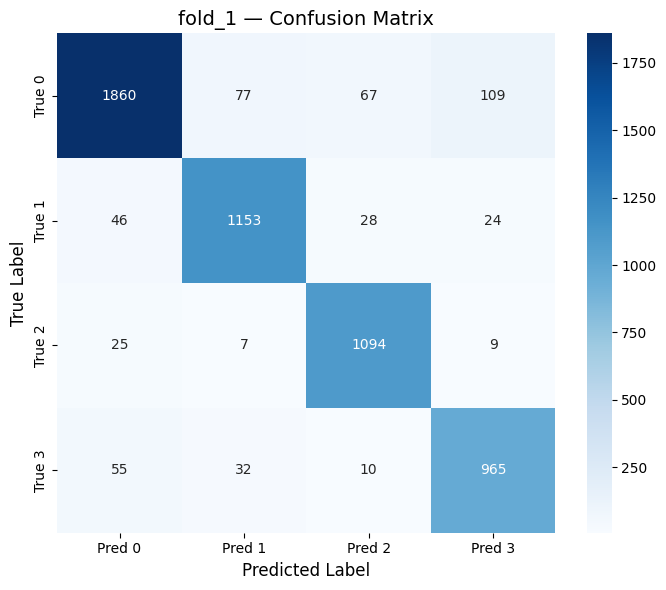


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9817
 F1 Score 0.9125
Precision 0.9073
   Recall 0.9186
 Accuracy 0.9121


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.936556 0.880265
    1   0.908589 0.921663
    2   0.912427 0.963877
    3   0.871725 0.908663


🌀 Fold 2/5


Training fold 2: 100%|██████████| 50/50 [00:31<00:00,  1.58it/s, loss=0.2604]


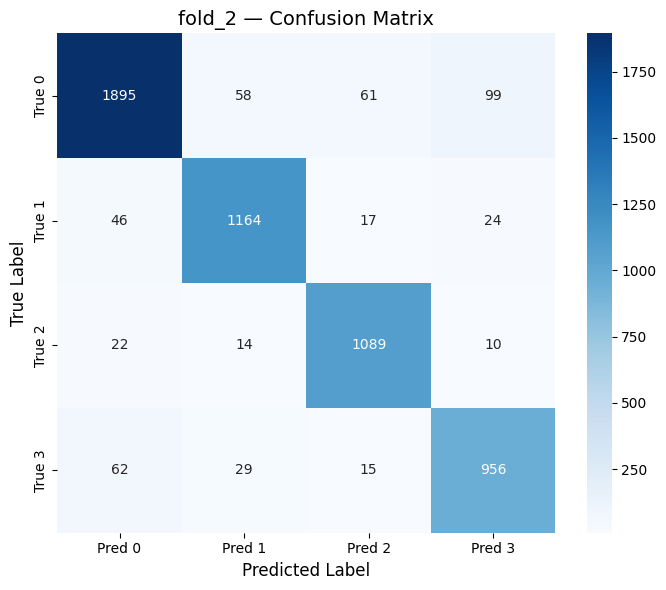


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9827
 F1 Score 0.9175
Precision 0.9138
   Recall 0.9217
 Accuracy 0.9178


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.935802 0.896829
    1   0.920158 0.930456
    2   0.921320 0.959471
    3   0.877870 0.900188


🌀 Fold 3/5


Training fold 3: 100%|██████████| 50/50 [00:32<00:00,  1.56it/s, loss=0.2638]


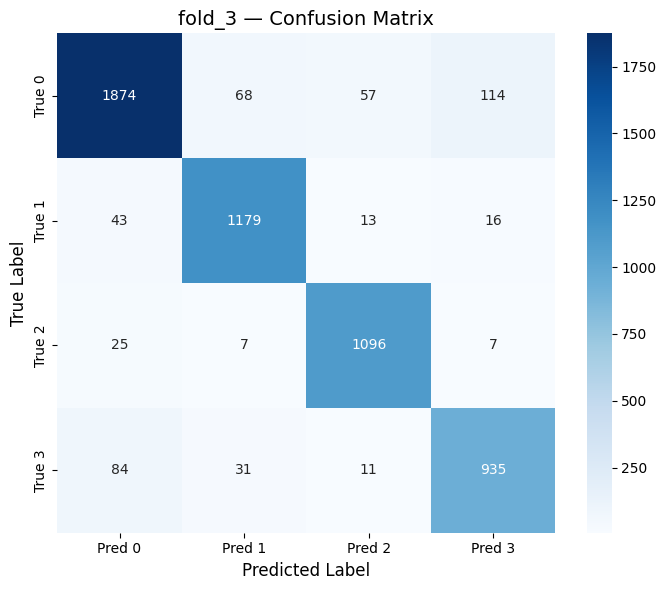


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9837
 F1 Score 0.9150
Precision 0.9115
   Recall 0.9191
 Accuracy 0.9144


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.924975 0.886891
    1   0.917510 0.942446
    2   0.931181 0.965639
    3   0.872201 0.881244


🌀 Fold 4/5


Training fold 4: 100%|██████████| 50/50 [00:31<00:00,  1.58it/s, loss=0.2665]


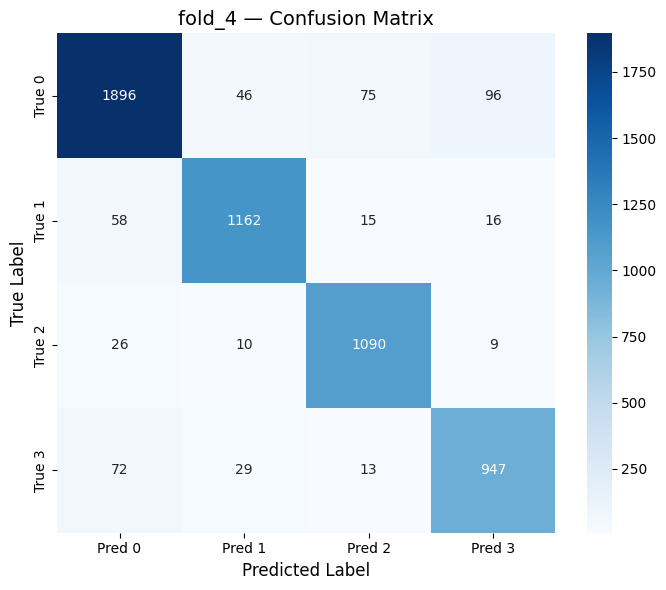


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9834
 F1 Score 0.9167
Precision 0.9140
   Recall 0.9198
 Accuracy 0.9164


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.923977 0.897302
    1   0.931836 0.928857
    2   0.913663 0.960352
    3   0.886704 0.892554


🌀 Fold 5/5


Training fold 5: 100%|██████████| 50/50 [00:32<00:00,  1.54it/s, loss=0.2651]


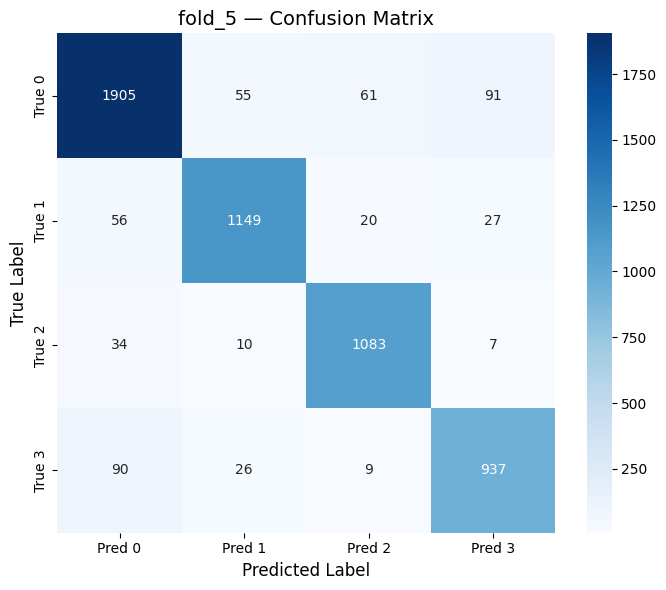


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9824
 F1 Score 0.9128
Precision 0.9115
   Recall 0.9143
 Accuracy 0.9126


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.913669 0.901989
    1   0.926613 0.917732
    2   0.923274 0.955026
    3   0.882298 0.882298



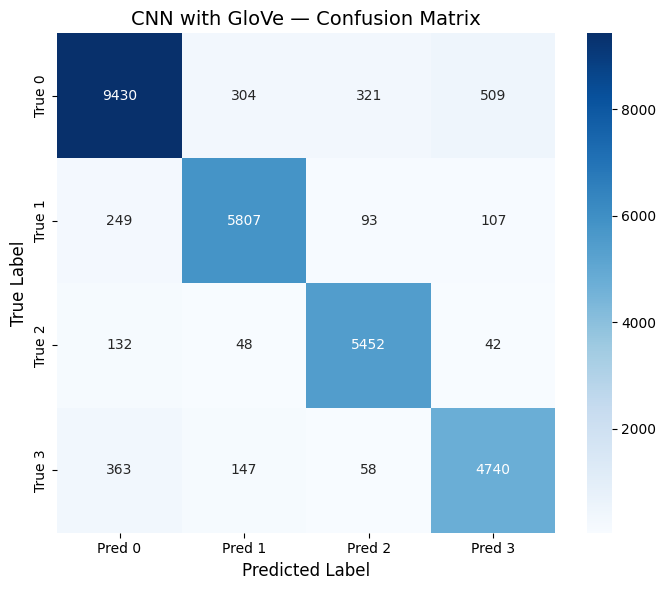

CPU times: total: 2min 55s
Wall time: 2min 51s


ClassificationMetrics(name='CNN with GloVe', training_time=159.95003429998178, estimators=[{'preprocessor': SequenceVectorizer(max_length=1000, pad_left=False,
                   vocabulary={'!': 807, '"': 10, '#': 2751, '$': 82, '%': 264,
                               '&': 1163, '&amp;': 725, "'": 59, "''": 29,
                               "'50s": 17347, "'60s": 11122, "'70s": 10964,
                               "'80s": 11320, "'90s": 11437, "'d": 1153,
                               "'em": 10806, "'ll": 771, "'m": 474, "'n": 18701,
                               "'n'": 12556, "'re": 269, "'s": 11, "'ve": 464,
                               '(': 25, '(212)': 16047, '(800)': 13105, ')': 26,
                               '*': 13699, '+': 3280, ',': 3, ...}), 'model': GloveCNNForCategoryClassification(
  (embedding): Embedding(20003, 100, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv): Conv1d(100, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max

In [39]:
%%time

glove_cnn_metrics = cross_validate_model(
    model=glove_cnn_model,
    X=data_nn['description'],
    y=data_nn['category_id'],
    preprocessor=glove_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='CNN with GloVe'
)

glove_cnn_metrics

Процесс обучения прошел быстрее благодаря меньшему количеству обучаемых параметров, однако метрики стали хуже

## Сравнение качества полученных моделей

Сравним качество базового решения с нейросетями с помощью тепловой карты

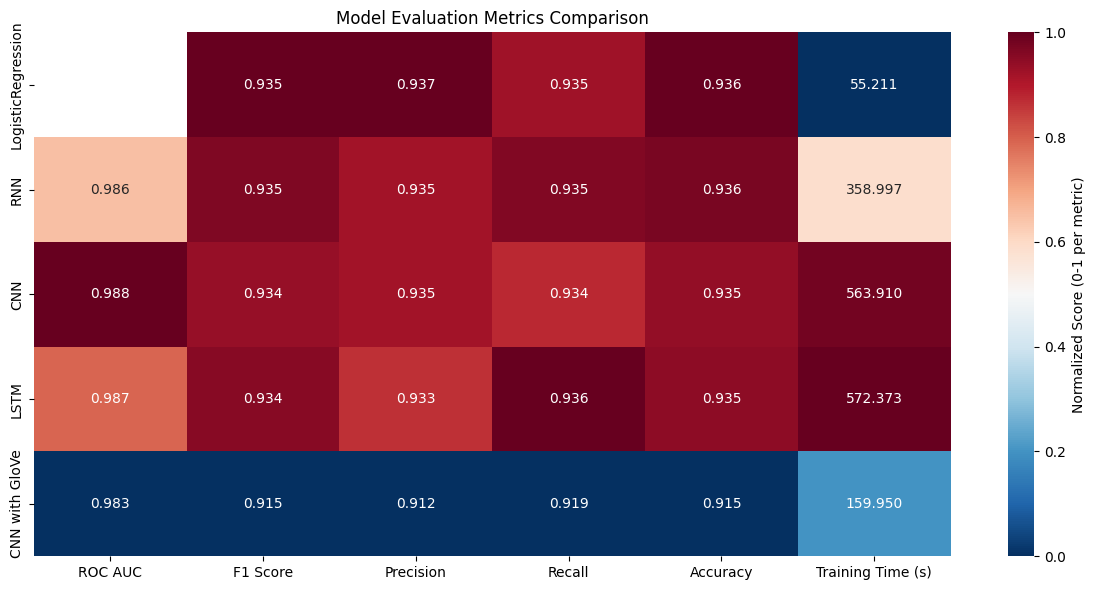

In [56]:
plot_metrics_heatmap([
    baseline_metrics,
    rnn_metrics,
    cnn_metrics,
    lstm_metrics,
    glove_cnn_metrics
])

Лучший результат все еще показала комбинация `CountVectorizer` и `LogisticRegression` без удаления стоп-слов и пунктуации. Потом примерно одинаково идут RNN, CNN и LSTM, после них внизу рейтинга расположился CNN + GloVe

В дальнейшем можно сравнить лучший алгоритм этого шага с подходами, связанными с дообучением существующих LLM (transfer learning)